In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
result_dir = Path('/data1/tpz/nwm-main/results/nwm_cdit_airvln_2d/airvln/CEM_N21_K5_RS1_rep3_OPT1')

In [52]:
idx = 14

In [53]:
data_dir = result_dir / f'id_{idx}' / 'preds_0.pth'

In [54]:
data = torch.load(data_dir)

In [55]:
data['loss']

tensor(0.5078, device='cuda:2', dtype=torch.bfloat16)

In [56]:
batch_idx = 0

In [57]:
obs = data["obs_image"][batch_idx]
goal = data["goal_image"][batch_idx]
preds = data["nwm_preds"][batch_idx]
action = data["deltas"][batch_idx]
gt = data["gt_actions"][batch_idx]
preds_completed = data["preds_completed"][batch_idx]

In [58]:
print("obs.shape:", obs.shape)
print("goal.shape:", goal.shape)
print("preds.shape:", preds.shape)
print("actions.shape:", action.shape)
print("gt.shape:", gt.shape)
print("preds_completed.shape:", preds_completed.shape)

obs.shape: torch.Size([3, 224, 224])
goal.shape: torch.Size([3, 224, 224])
preds.shape: torch.Size([224, 224])
actions.shape: torch.Size([3])
gt.shape: torch.Size([3])
preds_completed.shape: torch.Size([3, 224, 224])


In [59]:
obs = obs.cpu()
preds = preds.cpu().float()
action = action.cpu()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


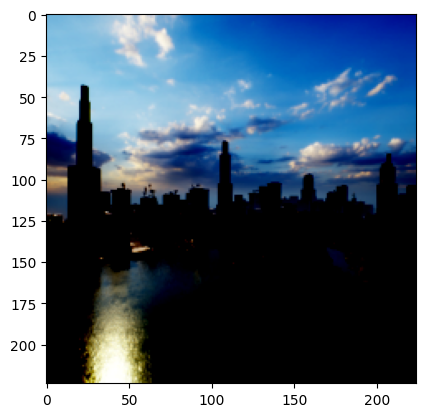

In [60]:
plt.imshow(obs.permute(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


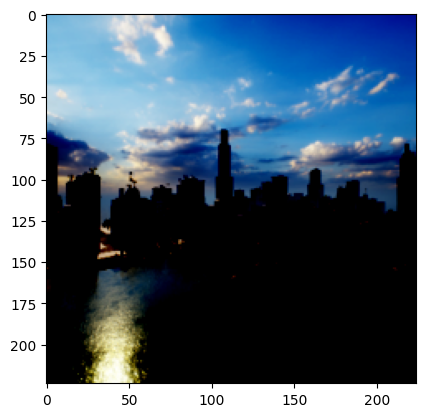

In [61]:
plt.imshow(goal.permute(1, 2, 0))

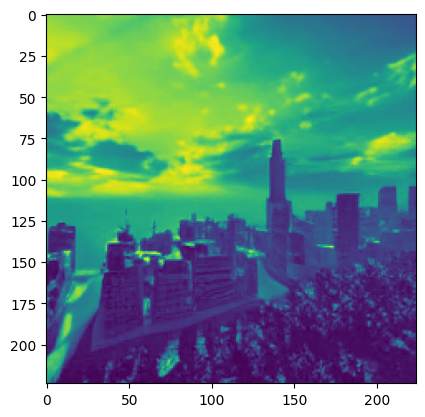

In [62]:
plt.imshow(preds)

In [63]:
action

tensor([-0.1097,  0.0142,  0.0676])

In [64]:
gt

tensor([1.5198e+00, 3.8672e-16, 0.0000e+00])

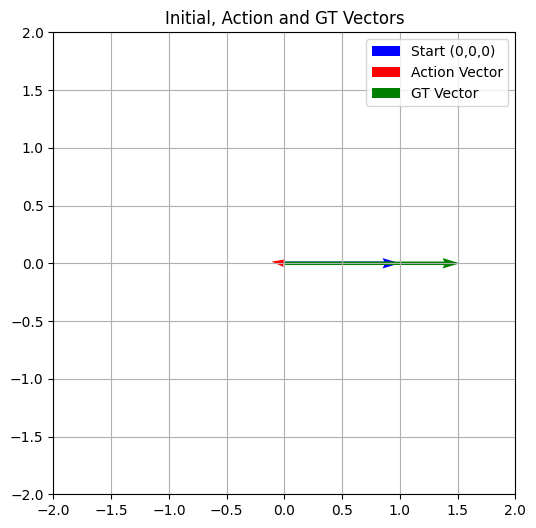

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# 初始向量起点和方向（假设为0向量）
start_pose = np.array([0.0, 0.0, 0.0])

# action 和 gt 向量
action_np = action.cpu().numpy()
gt_np = gt.cpu().numpy()

dx_a, dy_a, dtheta_a = action_np
dx_g, dy_g, dtheta_g = gt_np

# 初始向量（0,0），画一个单位箭头表示朝向0度
origin = np.array([0, 0])
init_vec = np.array([np.cos(start_pose[2]), np.sin(start_pose[2])])

# action向量，考虑旋转后的dx, dy
h = start_pose[2]
action_vec = np.array([
    dx_a * np.cos(h) - dy_a * np.sin(h),
    dx_a * np.sin(h) + dy_a * np.cos(h)
])

# gt向量，考虑旋转后的dx, dy
gt_vec = np.array([
    dx_g * np.cos(h) - dy_g * np.sin(h),
    dx_g * np.sin(h) + dy_g * np.cos(h)
])

plt.figure(figsize=(6, 6))
plt.quiver(*origin, *init_vec, angles='xy', scale_units='xy', scale=1, color='blue', label='Start (0,0,0)')
plt.quiver(*origin, *action_vec, angles='xy', scale_units='xy', scale=1, color='red', label='Action Vector')
plt.quiver(*origin, *gt_vec, angles='xy', scale_units='xy', scale=1, color='green', label='GT Vector')

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Initial, Action and GT Vectors")
plt.show()